In [13]:
pip install imbalanced-learn xgboost streamlit joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
# ==========================================
# 1️⃣ Import Libraries
# ==========================================
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [15]:

# ==========================================
# 2️⃣ Load Dataset
# ==========================================
df = pd.read_csv("healthcare-dataset-stroke-data for depoly streamlit.csv")

In [16]:
print(df.head())
print(df.info())


      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 e

In [17]:
# ==========================================
# 3️⃣ Basic Cleaning
# ==========================================
df.drop("id", axis=1, inplace=True)

# Fill missing BMI
df["bmi"].fillna(df["bmi"].median(), inplace=True)


C:\Users\nisha\AppData\Local\Temp\ipykernel_7592\1004158176.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bmi"].fillna(df["bmi"].median(), inplace=True)


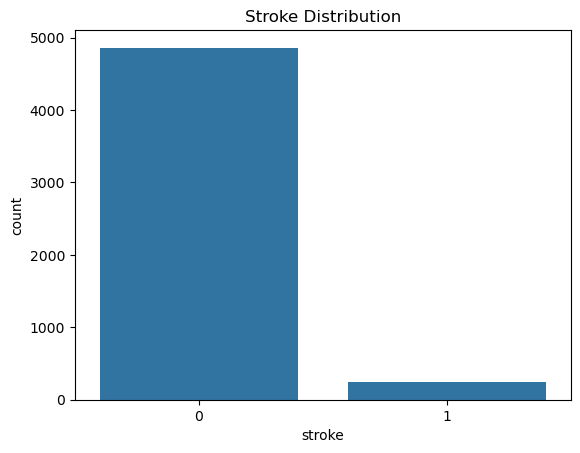

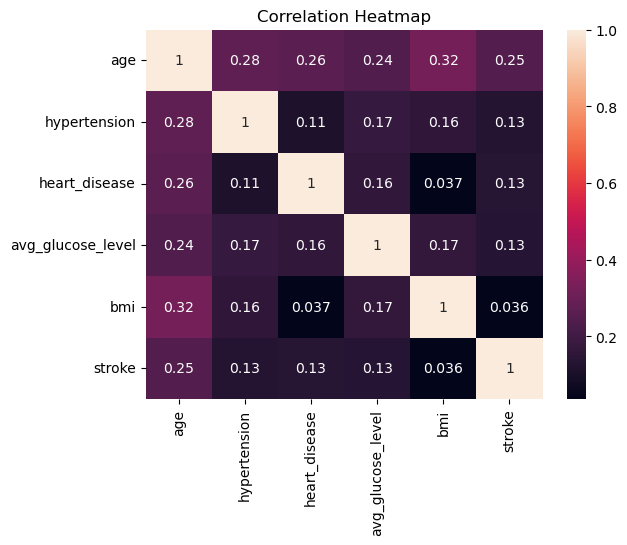

In [18]:
# ==========================================
# 4️⃣ EDA
# ==========================================
plt.figure()
sns.countplot(x="stroke", data=df)
plt.title("Stroke Distribution")
plt.show()

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [7]:
# ==========================================
# 5️⃣ Split Features & Target
# ==========================================
X = df.drop("stroke", axis=1)
y = df["stroke"]

# Categorical & Numerical columns
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns


In [8]:

# ==========================================
# 6️⃣ Preprocessing Pipeline
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


In [9]:
# ==========================================
# 7️⃣ Train Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [10]:
# ==========================================
# 8️⃣ Handle Imbalanced Data
# ==========================================
X_train_processed = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed, y_train
)

X_test_processed = preprocessor.transform(X_test)

In [11]:

# ==========================================
# 9️⃣ Models
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

results = []

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_processed)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print("\n", "="*40)
    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))



Logistic Regression
Accuracy: 0.7524461839530333
Precision: 0.1413427561837456
Recall: 0.8
F1 Score: 0.24024024024024024

Confusion Matrix:
[[729 243]
 [ 10  40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.78      0.55      1022
weighted avg       0.95      0.75      0.82      1022


Decision Tree
Accuracy: 0.8845401174168297
Precision: 0.08536585365853659
Recall: 0.14
F1 Score: 0.10606060606060606

Confusion Matrix:
[[897  75]
 [ 43   7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       972
           1       0.09      0.14      0.11        50

    accuracy                           0.88      1022
   macro avg       0.52      0.53      0.52      1022
weighted avg       0.91      

                 Model  Accuracy  Precision  Recall        F1
0  Logistic Regression  0.752446   0.141343    0.80  0.240240
1        Decision Tree  0.884540   0.085366    0.14  0.106061
2        Random Forest  0.921722   0.105263    0.08  0.090909
3                  SVM  0.787671   0.111628    0.48  0.181132
4                  KNN  0.811155   0.096045    0.34  0.149780
5          Naive Bayes  0.341487   0.067961    0.98  0.127108
6              XGBoost  0.927593   0.184211    0.14  0.159091


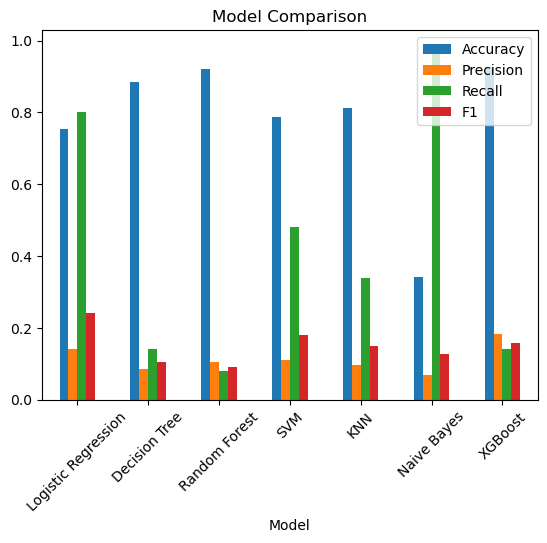

In [12]:
# ==========================================
# 🔟 Compare All Models
# ==========================================
results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
print(results_df)

results_df.set_index("Model").plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

In [19]:
# ==========================================
# 6️⃣ Hyperparameter Tuning
# ==========================================
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

NameError: name 'pipeline' is not defined

C:\Users\nisha\AppData\Local\Temp\ipykernel_7592\4168389249.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bmi"].fillna(df["bmi"].median(), inplace=True)


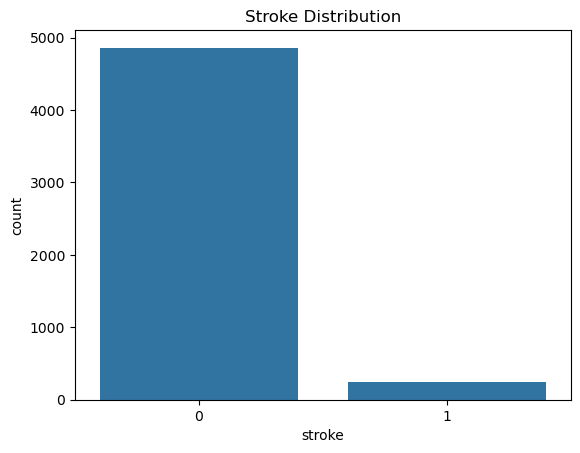

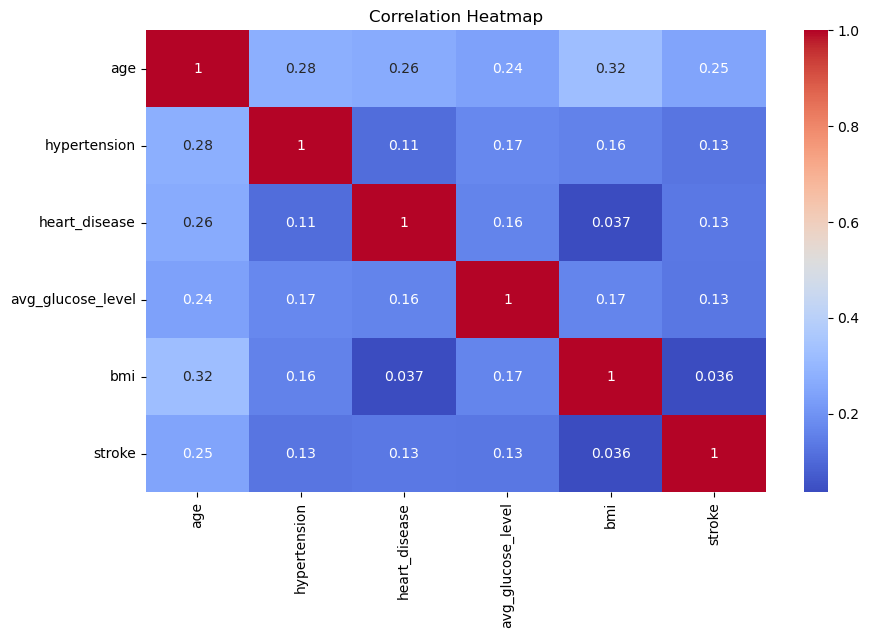


Logistic Regression
Accuracy: 0.7524461839530333
Precision: 0.1413427561837456
Recall: 0.8
F1 Score: 0.24024024024024024


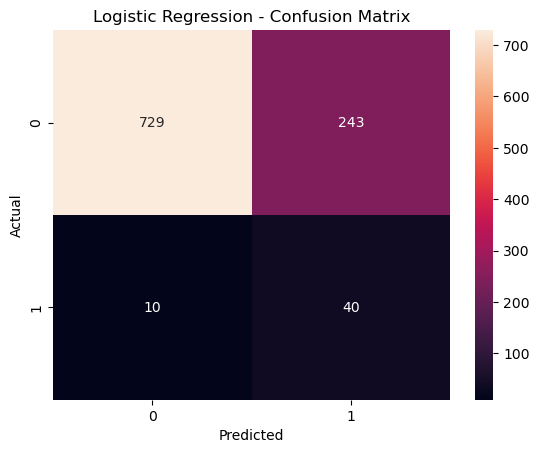


Decision Tree
Accuracy: 0.8874755381604696
Precision: 0.08860759493670886
Recall: 0.14
F1 Score: 0.10852713178294573


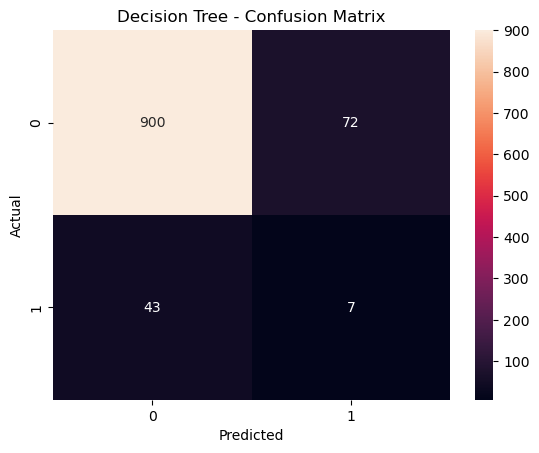


Random Forest
Accuracy: 0.923679060665362
Precision: 0.1111111111111111
Recall: 0.08
F1 Score: 0.09302325581395349


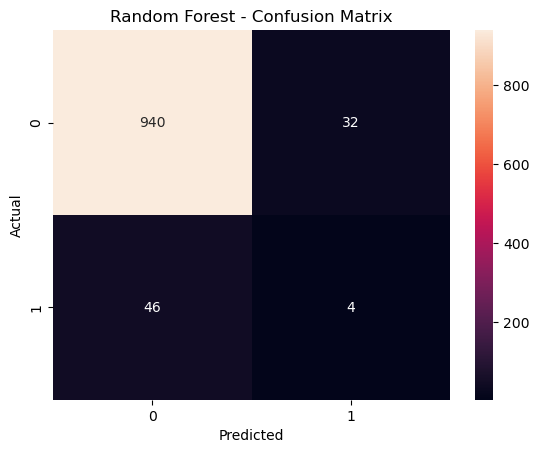


SVM
Accuracy: 0.7876712328767124
Precision: 0.11162790697674418
Recall: 0.48
F1 Score: 0.1811320754716981


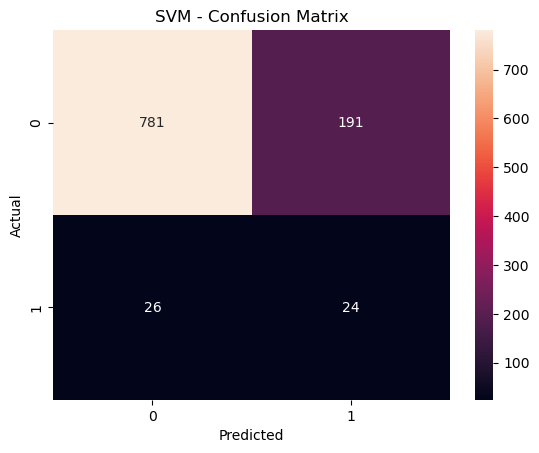


KNN
Accuracy: 0.8111545988258317
Precision: 0.096045197740113
Recall: 0.34
F1 Score: 0.14977973568281938


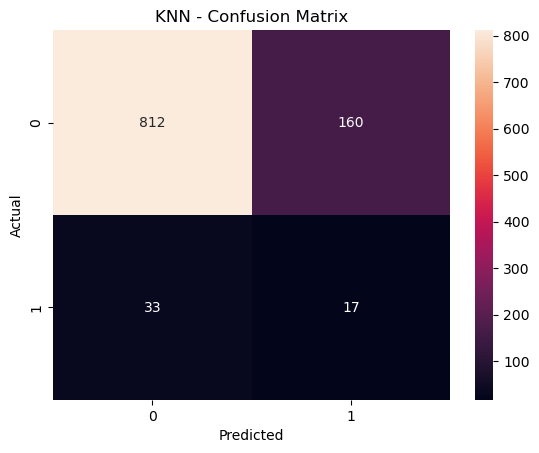


Naive Bayes
Accuracy: 0.34148727984344424
Precision: 0.06796116504854369
Recall: 0.98
F1 Score: 0.12710765239948119


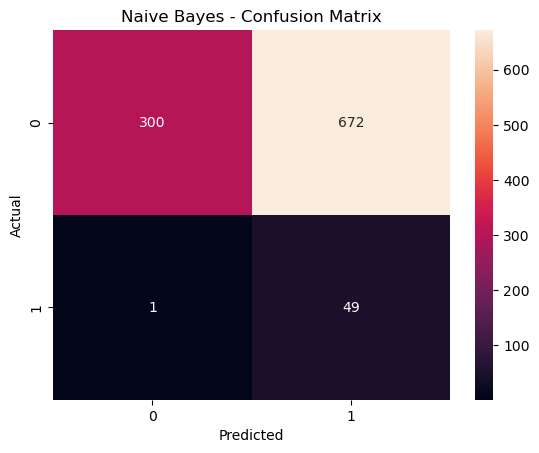

C:\Users\nisha\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [09:38:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy: 0.9275929549902152
Precision: 0.18421052631578946
Recall: 0.14
F1 Score: 0.1590909090909091


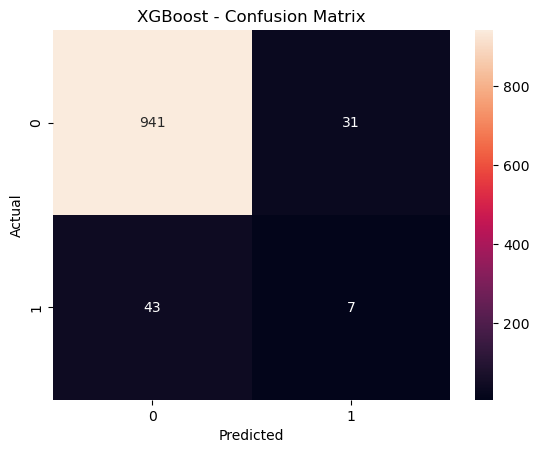


Model Comparison:

                 Model  Accuracy  Precision  Recall        F1
0  Logistic Regression  0.752446   0.141343    0.80  0.240240
1        Decision Tree  0.887476   0.088608    0.14  0.108527
2        Random Forest  0.923679   0.111111    0.08  0.093023
3                  SVM  0.787671   0.111628    0.48  0.181132
4                  KNN  0.811155   0.096045    0.34  0.149780
5          Naive Bayes  0.341487   0.067961    0.98  0.127108
6              XGBoost  0.927593   0.184211    0.14  0.159091


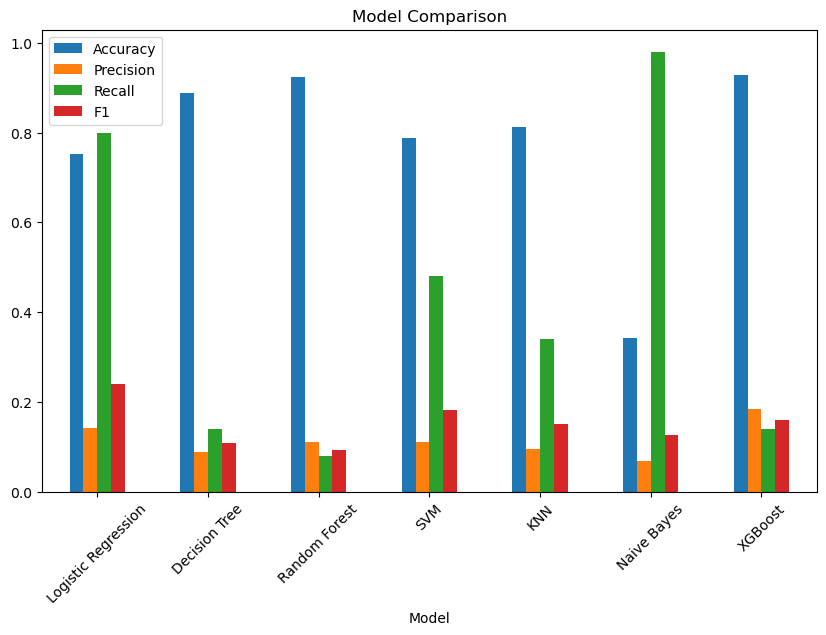

Model saved at: G:\DATASCIENCE\heartstroke ml project\stroke_best_model.joblib


In [26]:
# =====================================================
# 1️⃣ Import Libraries
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# =====================================================
# 2️⃣ Load Dataset
# =====================================================
df = pd.read_csv("healthcare-dataset-stroke-data for depoly streamlit.csv")

# =====================================================
# 3️⃣ Cleaning
# =====================================================
df.drop("id", axis=1, inplace=True)
df["bmi"].fillna(df["bmi"].median(), inplace=True)

# =====================================================
# 4️⃣ EDA
# =====================================================
plt.figure()
sns.countplot(x="stroke", data=df)
plt.title("Stroke Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =====================================================
# 5️⃣ Split Features & Target
# =====================================================
X = df.drop("stroke", axis=1)
y = df["stroke"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# =====================================================
# 6️⃣ Train Test Split
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 7️⃣ Preprocessing
# =====================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# =====================================================
# 8️⃣ All Algorithms
# =====================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric="logloss", use_label_encoder=False)
}

results = []
best_f1 = 0
best_model = None
best_model_name = ""

# =====================================================
# 9️⃣ Train Models with SMOTE
# =====================================================
for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    # Save Best Model
    if f1 > best_f1:
        best_f1 = f1
        best_model = pipeline
        best_model_name = name

    print("\n", "="*50)
    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =====================================================
# 🔟 Compare All Models
# =====================================================
results_df = pd.DataFrame(results,
                          columns=["Model","Accuracy","Precision","Recall","F1"])

print("\nModel Comparison:\n")
print(results_df)

results_df.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

# =====================================================
# 1️⃣1️⃣ GridSearchCV on Best Model (if XGBoost)
# =====================================================
if best_model_name == "XGBoost":

    param_grid = {
        "model__n_estimators": [200,300],
        "model__max_depth": [4,6],
        "model__learning_rate": [0.05,0.1]
    }

    grid = GridSearchCV(
        best_model,
        param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    print("Best Parameters:", grid.best_params_)

# =====================================================
# 1️⃣2️⃣ Save Best Model
# =====================================================
import joblib
import os

# Save inside same project folder
model_path = r"G:\DATASCIENCE\heartstroke ml project\stroke_best_model.joblib"

joblib.dump(best_model, model_path)

print("Model saved at:", model_path)

In [24]:
import joblib
import pandas as pd

model = joblib.load("stroke_best_model.joblib")

# Example input (must match training columns)
sample = pd.DataFrame([{
    "gender": "Male",
    "age": 67,
    "hypertension": 0,
    "heart_disease": 1,
    "ever_married": "Yes",
    "work_type": "Private",
    "Residence_type": "Urban",
    "avg_glucose_level": 228.69,
    "bmi": 36.6,
    "smoking_status": "formerly smoked"
}])

prediction = model.predict(sample)
print(prediction)

[1]
